Colunas disponíveis no dataset:
['Game Title', 'Publisher', 'Release Year', 'Platforms', 'Genre', 'Global Sales (Millions)', 'Units Sold (Approx.)', 'Metacritic Score']

Primeiras 5 linhas do dataset:


,Game Title,Publisher,Release Year,Platforms,Genre,Global Sales (Millions),Units Sold (Approx.),Metacritic Score
0,Elden Ring,Bandai Namco,2022,"PC, PS4/5, Xbox One/Series",Action RPG,25.0,25000000,96
1,Hogwarts Legacy,WB Games,2023,"PC, PS5, Xbox Series, Switch",Action RPG,24.0,24000000,84
2,The Legend of Zelda: TotK,Nintendo,2023,Switch,Action-Adventure,20.0,20280000,96
3,Call of Duty: MWII (2022),Activision,2022,"PC, PS4/5, Xbox One/Series",FPS,30.0,30000000,76
4,Pokémon Scarlet/Violet,Nintendo,2022,Switch,RPG,24.9,24920000,72



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               10 non-null     object 
 1   Publisher                10 non-null     object 
 2   Release Year             10 non-null     object 
 3   Platforms                10 non-null     object 
 4   Genre                    10 non-null     object 
 5   Global Sales (Millions)  10 non-null     float64
 6   Units Sold (Approx.)     10 non-null     int64  
 7   Metacritic Score         10 non-null     int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 772.0+ bytes

Estatísticas descritivas:
       Global Sales (Millions)  Units Sold (Approx.)  Metacritic Score
count                10.000000          1.000000e+01         10.000000
mean                 44.060000          4.460600e+07         88.900000
std                  53.5

<ipython-input-19-2018fb98d2c0>:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")


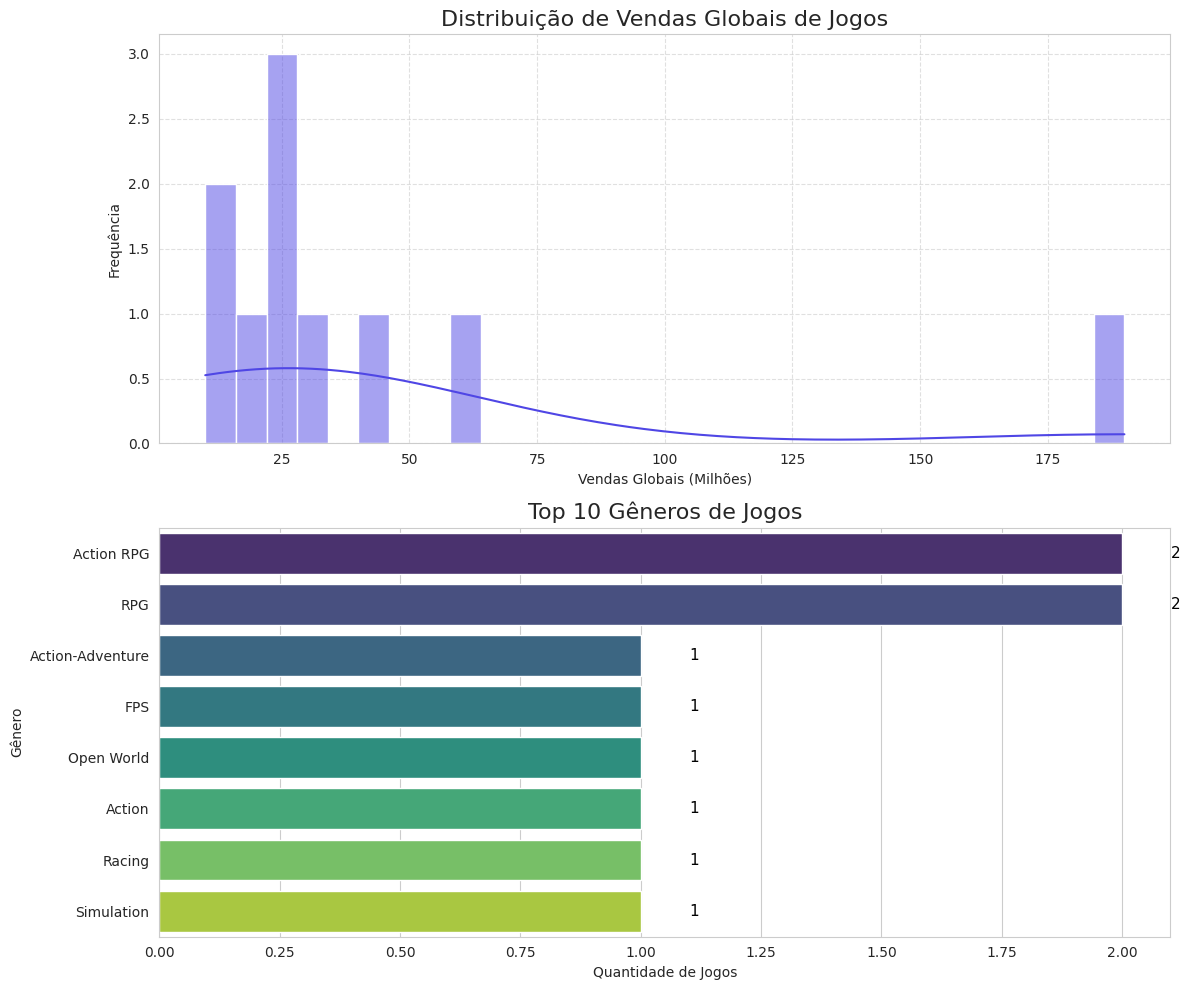

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Configurar estilo geral dos gráficos
sns.set_style("whitegrid")

# Carregar o dataset uma vez
df = pd.read_csv("games_sales.csv")

# --- Análise inicial ---

print("Colunas disponíveis no dataset:")
print(df.columns.tolist())

print("\nPrimeiras 5 linhas do dataset:")
display(df.head())  # Se Jupyter, melhor visual

print("\nInformações do DataFrame:")
df.info()

print("\nEstatísticas descritivas:")
print(df.describe())

print("\nContagem de valores nulos por coluna:")
print(df.isnull().sum())

print("\nValores únicos nas colunas categóricas:")
for col in ['Game Title', 'Publisher', 'Platforms', 'Genre']:
    unique_vals = df[col].nunique()
    print(f"- {col}: {unique_vals} valores únicos")

# --- Visualizações ---

plt.figure(figsize=(12, 10))

# 1 - Histograma de vendas globais
plt.subplot(2, 1, 1)
sns.histplot(df['Global Sales (Millions)'], bins=30, kde=True, color="#4F46E5")
plt.title("Distribuição de Vendas Globais de Jogos", fontsize=16)
plt.xlabel("Vendas Globais (Milhões)")
plt.ylabel("Frequência")
plt.grid(True, linestyle='--', alpha=0.6)

# 2 - Gráfico de barras top 10 gêneros
plt.subplot(2, 1, 2)
top_generos = df['Genre'].value_counts().head(10)
ax = sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")
plt.title("Top 10 Gêneros de Jogos", fontsize=16)
plt.xlabel("Quantidade de Jogos")
plt.ylabel("Gênero")

for i, v in enumerate(top_generos.values):
    ax.text(v + 0.1, i, str(v), color='black', va='center', fontsize=11)

plt.tight_layout()
plt.show()

